In [14]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [15]:
insurance_data = pd.read_csv("insurance.csv")

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns = ["region"], drop_first = True, dtype = int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker_interaction"]= X["age"] * X["smoker"]
X["bmi_smoker"]= X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alpha=0.01:  20920713.85887192
MSE for alpha=0.1:  20904627.387111425
MSE for alpha=1:  20815963.249536242
MSE for alpha=10:  21236465.19443409
MSE for alpha=20:  21587617.432979893
MSE for alpha=40:  21909410.254583035
MSE for alpha=60:  22066210.77431052
MSE for alpha=80:  22163674.545048878
MSE for alpha=100:  22232440.95504468


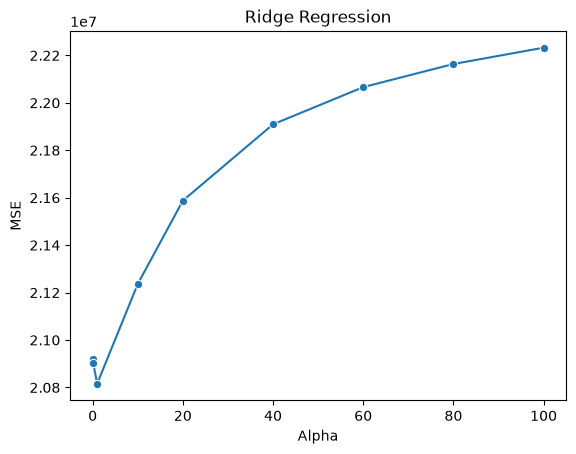

In [16]:
import seaborn as sns 
import matplotlib.pyplot as plt

alpha_values = [0.01, 0.1, 1, 10, 20, 40, 60, 80, 100]
mses = []

for a in alpha_values:
    ridge_model = Ridge(alpha = a)
    ridge_model.fit(X_train, y_train)

    y_pred = ridge_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha={a}: ", mse)
    mses.append(mse)

sns.lineplot(x=alpha_values, y=mses, marker = "o")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Ridge Regression")
plt.show()


In [17]:
from sklearn.linear_model import RidgeCV
aplpha_values = [0.01, 0.001,0.1, 1, 10, 20, 40, 60, 80, 100]

ridge_cv_model = RidgeCV(alphas=aplpha_values, scoring='neg_mean_squared_error', cv=5)
ridge_cv_model.fit(X_train, y_train)
print("Best alpha value: ", ridge_cv_model.alpha_)

y_pred_cv = ridge_cv_model.predict(X_test)
mse_cv = mean_squared_error(y_test, y_pred_cv)
r2 = r2_score(y_test, y_pred)
print("mse = ", mse)
print("s2 = ", r2)

Best alpha value:  0.001
mse =  22232440.95504468
s2 =  0.8567947013710526
